# pyPCGA modflow inversion example

## Crosswell tomography

- Adapted from Application 1 of Lee and Kitanids [WRR 2014] 

(https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2014WR015483)

***

> We first generated 870 head observations using crosswell pumping tests (ln 9) from the reference log K field (ln 11) with USGS MODFLOW Flopy python interface.

> In specific, we extracted groundwater at a well and observed 29 stready-state hydraulic heads at the remaining monitoring wells. We repeated these crosswell pumping tests for all 30 well locations (ln 11).  

> Then add the noise (std = 0.5) to observations. Using observations with MODFLOW, can we reconstruct the reference field (ln 11)?

Note the example is not exactly same as Application 1 in Lee and Kitanidis [2014]

Also, the number of MODFLOW simulations is higher than what they reported because we turned on Levenberg-Marquardt and Line Search options in this example. Those additional optimization routines increases the inversion time, but usually results in a very accurate inverse solution even for highly nonlinear problems. 

***

- Parameters

|Description           |                      |   Value |            
|----------------------|:----------------------------------:|:---------------------------:|
|*Geomteric parameters*                          | |       |                                               
| Lx, Ly        | Domain length and width (m)        |        1000, 750|         
| Q             | Pumping rates (m^2/d)              |            25 |           
| Rch           | Recharge rates (m/d)               |           0.001|          
| dx, dy        | Grid size (m)                      |            10|            
|*Geostatistical parameters*     ||                      |                        
| reference mean(logK)    | mean for the reference log K (ln m/d) |            2.5  |          
| reference q(x,x')       | Covariance kernel for the reference log K                  | q(x,x') = 0.002^3 (x-x')^3 |
| q(x,x')            | Covariance kernel used in inversion | q(x,x') = exp(-x/250) |
|*Measurement Error* ||  |
| nobs | Number of measurement | 870 |
| R | Variance of measurement error (m) | 0.5^2 |


In [1]:
import os
import logging
import copy
from pathlib import Path
from typing import Generator, List, Tuple
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.animation import HTMLWriter
from matplotlib.colors import LogNorm
from IPython.display import HTML
import nested_grid_plotter as npg
import pyrtid
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
from pyrtid.utils import (
    indices_to_node_number,
    node_number_to_indices,
    extract_hess_inv_diag,
)
from pyrtid.inverse.params import update_parameters_from_model
from pyrtid.inverse.loss_function import (
    get_model_ls_loss_function,
    get_model_reg_loss_function,
)
from pyrtid.inverse.regularization import (
    GeostatisticalRegularizator,
    FFTCovarianceMatrix,
    DenseCovarianceMatrix,
    cov_mat_to_ud_mat,
)
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy import ndimage

/tmp/ipykernel_26092/1303257182.py:45: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage import gaussian_filter


- Check package/software versions

In [2]:
logging.info(f"pyrtid.__version__ = {pyrtid.__version__}")
logging.info(f"nested_grid_plotter.__version__ = {nested_grid_plotter.__version__}")

- Type hints definition for numpy arrays

In [3]:
NDArrayFloat = np.typing.NDArray[np.float64]
NDArrayInt = np.typing.NDArray[np.int64]

- Create a directory to store the exported figures

In [4]:
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
fig_save_path = Path(ipynb_path, "exported_figures")
fig_save_path.mkdir(parents=True, exist_ok=True)  # make sure that the directory exists

- Set-up logging level

In [5]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("this is a test")

INFO:root:this is a test


- Define some configurations for the plots

In [6]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # required for the plot to update
plt.rcParams.update(new_rc_params)

## Forward problem

- Grid definition

In [7]:
nx = 22
ny = 11
nz = 1
dx = 5.5  # m
dy = 7.6  # m
dz = 1

- Location of pumping wells (obs_locmat)

In [8]:
obs_locmat = np.zeros((nz, ny, nx), dtype=bool)
obs_locs: List[Tuple[int, int]] = []
# for i in range(5, 71, 16):  # y
#    for j in range(9, 96, 16):  # x
for i, j in [(5, 6), (5, 14)]:
    obs_locmat[0, i, j] = 1
    obs_locs.append((j, i))

Q_locs_idx = np.where(obs_locmat == True)
Q_locs = []
for Q_loc in zip(Q_locs_idx[0], Q_locs_idx[1], Q_locs_idx[2]):
    Q_locs.append(Q_loc)

- x,y coordinates for plotting

In [9]:
x = np.linspace(0.0 + dx / 2.0, nx * dx - dx / 2.0, nx)
y = np.linspace(0.0 + dy / 2.0, ny * dy - dy / 2.0, ny)
XX, YY = np.meshgrid(x, y)
pts = np.hstack((XX.ravel()[:, np.newaxis], YY.ravel()[:, np.newaxis]))

- Pumping/monitoring well locations

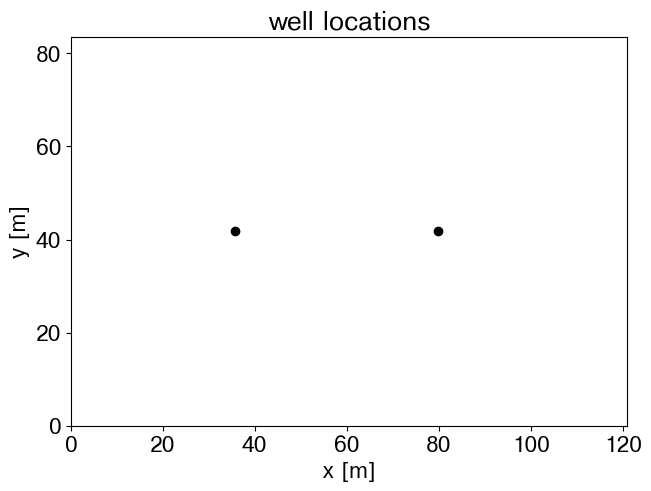

In [10]:
idx = np.where(obs_locmat == 1)
for i, j in zip(idx[1], idx[2]):
    plt.plot(x[j], y[i], "ko")
plt.xlim(0, nx * dx)
plt.ylim(0, ny * dy)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("well locations")

fname = "well_locations"
for format in ["png", "pdf"]:
    plt.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- This example is Hydraulic tomography - crosswell pumping test setting
- Load reference value for comparison purpose with its plot

Note: in the demonstrator, we can adjust the permeability (m/s), so we need to convert these values to permeability ones



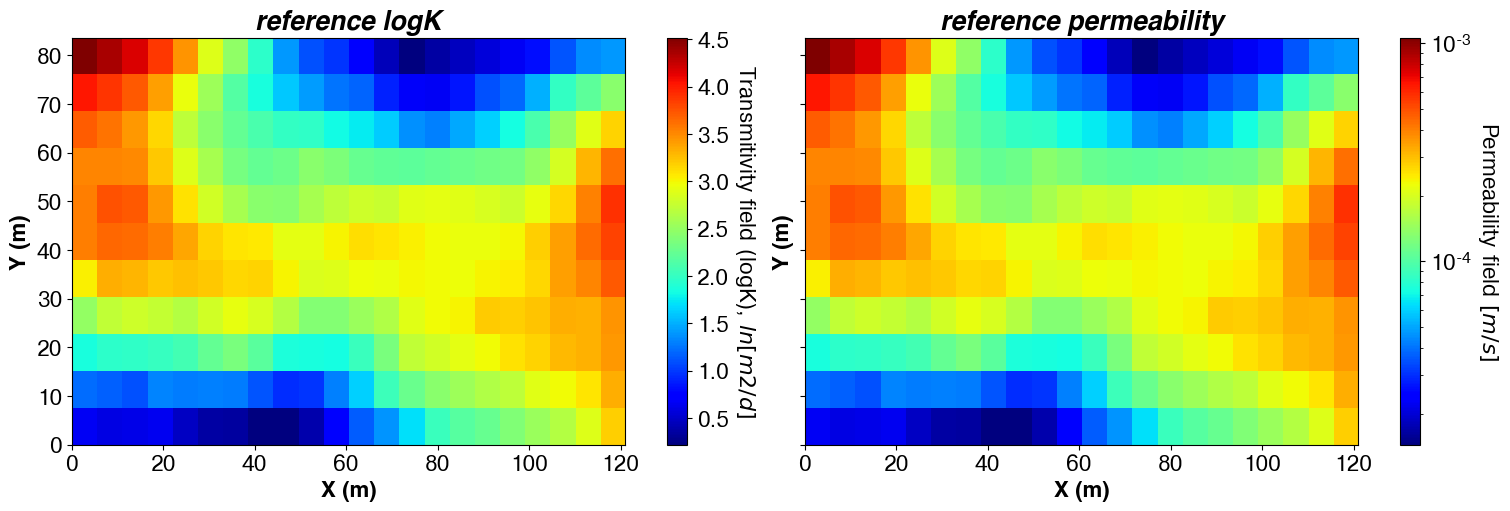

In [11]:
def log_transmitivity_to_permeability(x: NDArrayFloat) -> NDArrayFloat:
    """Convert a transmitivity in ln[m2/d] to a permeability in [m/s]."""
    return np.exp(x) / 3600 / 24


def permeability_to_log_transmitivity(x: NDArrayFloat) -> NDArrayFloat:
    """Convert a permeability in [m/s] to a transmitivity in ln[m2/d]."""
    return np.log(x * 3600 * 24)


logT_reference: NDArrayFloat = (
    np.loadtxt("../../data/reference_logK.txt").reshape(75, 100).T
)

# resample from 100 x 75 to nx * ny
_XX, _YY = np.meshgrid(np.linspace(0.0, 100 - 1, nx), np.linspace(0, 75 - 1, ny))
_pts = np.hstack((_XX.ravel()[:, np.newaxis], _YY.ravel()[:, np.newaxis]))

logT_reference_2d = (
    ndimage.map_coordinates(logT_reference, coordinates=_pts.T).reshape(ny, nx).T
)
perm_reference_2d = log_transmitivity_to_permeability(logT_reference_2d)

plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (15, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True)
    },
)

# Plot the permeability
multi_imshow(
    axes=[plotter.get_axis("ax1-1")],
    fig=plotter.fig,
    data={"reference logK": logT_reference_2d},
    cbar_title="Transmitivity field (logK), $ln[m2/d]$",
    imshow_kwargs={"cmap": plt.get_cmap("jet"), "extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Y (m)",
)

multi_imshow(
    axes=[plotter.get_axis("ax1-2")],
    fig=plotter.fig,
    data={"reference permeability": perm_reference_2d},
    cbar_title="Permeability field $[m/s]$",
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "norm": LogNorm(),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
    },
    xlabel="X (m)",
    ylabel="Y (m)",
)

# Forward Model with PyRTID

- Creation of a base model

In [12]:
duration_in_days = 4
dt = 3600 * 24
nt = int(duration_in_days * 3600 * 24 / dt)
# Simulation on 31 days. We use a 4h timestep.
time_params = dmfwd.TimeParameters(
    duration=duration_in_s, dt_init=dt_init, dt_max=dt_max, dt_min=dt_min
)
geometry = dmfwd.Geometry(nx=nx, ny=ny, dx=dx, dy=dy)
fl_params = dmfwd.FlowParameters(
    permeability=8.0e-5,
    storage_coefficient=1e-3,
    regime=dmfwd.FlowRegime.STATIONARY,
    crank_nicolson=0.8,  # For the check, semi-implicit scheme
)

base_model = dmfwd.ForwardModel(geometry, time_params, fl_params)

- Add boundary conditions and regional recharge

In [13]:
# Add a regional recharge -> 35 m3/d = 35 / 3600 / 24 m3/s
flw_reg = 35.0 / 3600 / 24
recharge_source = dmfwd.SourceTerm(
    "aquifer_recharge",
    node_ids=np.arange(nx * ny),  # -> on the full domain
    times=np.arange(time_params.nt) * time_params.dt,
    flowrates=np.repeat(flw_reg, time_params.nt),
    concentrations=np.repeat(0.0, time_params.nt),
)
base_model.add_src_term(recharge_source)

# Boundary conditions
# Left border (x = 0) at 120 m
base_model.add_boundary_conditions(dmfwd.ConstantHead(span=(slice(0, 1), slice(None))))
base_model.fl_model.head[0, :, :] = 120.0
# Right border (x = xmax) at 110 m
base_model.add_boundary_conditions(
    dmfwd.ConstantHead(span=(slice(nx - 1, nx), slice(None)))
)
base_model.fl_model.head[-1, :, :] = 110.0

- Create the source terms for the pumping: one pumping test per day at -25 m3/h

In [14]:
for day in range(1, 3):
    ix, iy = obs_locs[day - 1]
    source_term = dmfwd.SourceTerm(
        "well pumping test # {day}",
        node_ids=np.array(
            indices_to_node_number(ix=ix, nx=nx, iy=iy, ny=ny)
        ),  # -> on the full domain
        times=np.array(day * time_params.dt),
        flowrates=np.array([-25.0 / 3600]),
        concentrations=np.array(0.0),
    )
    base_model.add_src_term(source_term)

- Check that the sources have been correctly defined: we plot the flowrate within time for the 30 wells: we see 30 intervals

In [15]:
span = node_number_to_indices(np.arange(nx * ny), nx=nx, ny=ny)[:-1]
src = base_model.get_fl_sources()

Text(0, 0.5, 'flowrates [m3/s]')

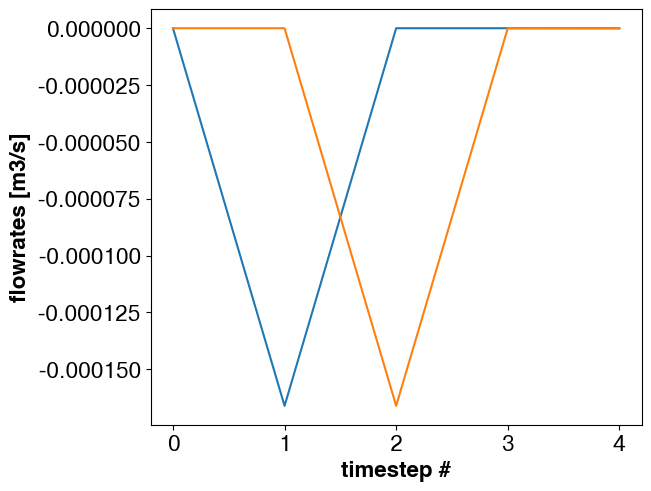

In [16]:
fl_sources = base_model.get_fl_sources()
fig, ax = plt.subplots()
for i in range(len(obs_locs)):
    ix, iy = obs_locs[i]
    ax.plot(fl_sources[ix, iy, :])
ax.set_xlabel("timestep #", fontweight="bold")
ax.set_ylabel("flowrates [m3/s]", fontweight="bold")

- Create two models with different permeabilities

In [17]:
# copy the base model
model_reference = copy.deepcopy(base_model)
# update permeability
model_reference.fl_model.permeability = perm_reference_2d
# solve the flow problem
dmfwd.ForwardSolver(model_reference).solve()

In [18]:
# copy the base model
model_estimate = copy.deepcopy(base_model)
# update permeability
model_estimate.fl_model.permeability[:, :] = log_transmitivity_to_permeability(1.0)
# solve the flow problem
dmfwd.ForwardSolver(model_estimate).solve()

In [19]:
model_reference.fl_model.head.shape

(22, 11, 5)

- Plot one time step

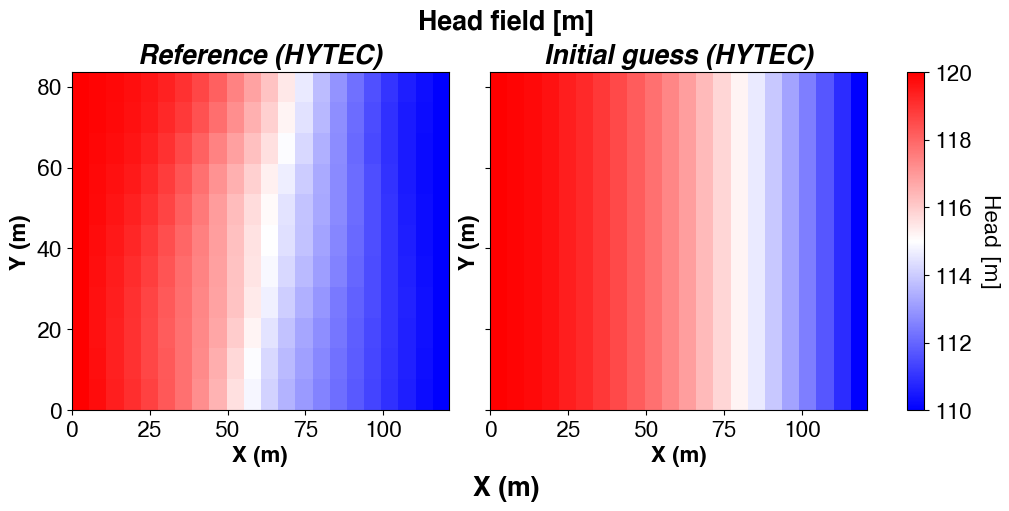

In [20]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True)
    },
)

time_index = 0
multi_imshow(
    axes=[plotter.get_axis(ax_name) for ax_name in ["ax1-1", "ax1-2"]],
    data={
        # Warning: observation 0 matches sample 1
        "Reference (HYTEC)": model_reference.fl_model.head[:, :, time_index],
        "Initial guess (HYTEC)": model_estimate.fl_model.head[:, :, time_index],
    },
    fig=plotter.fig,
    cbar_title="Head [m]",
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Y (m)",
)

plotter.subfigs["fig0"].suptitle("Head field [m]", fontweight="bold")
plotter.subfigs["fig0"].supxlabel("X (m)", fontweight="bold")

fname = "head_field_reference_vs_initial_guess"
for format in ["png", "pdf"]:
    plotter.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Make an animated version

In [21]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True)
    },
)

nb_frames = duration_in_days
plotter.animated_multi_imshow(
    ax_names=["ax1-1", "ax1-2"],
    data={
        "Reference (HYTEC)": model_reference.fl_model.head[:, :, :],
        "Initial guess (HYTEC)": model_estimate.fl_model.head[:, :, :],
    },
    cbar_title="Head [m]",
    nb_frames=nb_frames,
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Y (m)",
)

plotter.subfigs["fig0"].suptitle("Head field [m]", fontweight="bold")

plotter.close()
plotter.animate(nb_frames=nb_frames)

# Save the animation locally on the computer
fname_html = fig_save_path.joinpath(
    "head_field_reference_vs_initial_guess_animated.html"
)
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


- Compare the data from HYTEC with the one from MODFLOW for the "reference" model

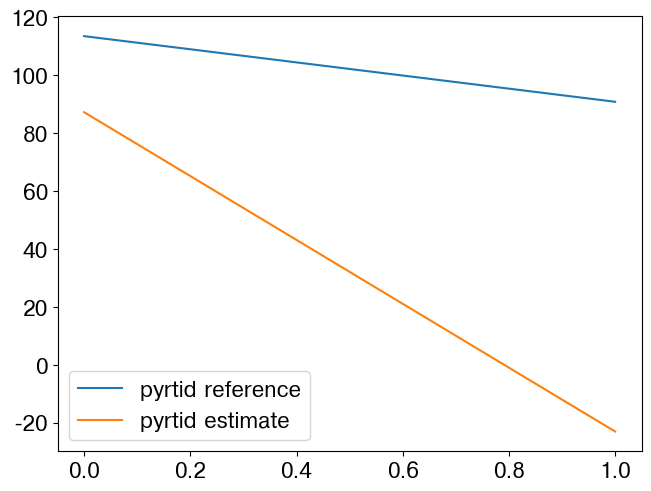

In [22]:
pumping_test_id = 1  # index of the well pumping test

dat_pyrtid_reference: NDArrayFloat = np.zeros(len(obs_locs))
dat_pyrtid_estimate: NDArrayFloat = np.zeros(len(obs_locs))

for i, obs_loc in enumerate(obs_locs):
    dat_pyrtid_reference[i] = model_reference.fl_model.head[
        :, :, (pumping_test_id + 1)
    ][obs_loc[0], obs_loc[1]]
    dat_pyrtid_estimate[i] = model_estimate.fl_model.head[:, :, (pumping_test_id + 1)][
        obs_loc[0], obs_loc[1]
    ]

plt.plot(dat_pyrtid_reference, label="pyrtid reference")
plt.plot(dat_pyrtid_estimate, label="pyrtid estimate")
plt.legend()

fname = f"heads_modflow_vs_hytec_for_pumping_test_{pumping_test_id}"
for format in ["png", "pdf"]:
    plt.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

In [23]:
noise_std = 0.3  # This is an absolute value
rng = np.random.default_rng(2021)


def make_noisy(x: NDArrayFloat) -> NDArrayFloat:
    """Return the input with some added white noise.

    Note
    ----
    The parameters are hardcoded to be consistent in the notebook.
    Change the function directly.
    """
    mean_noise = 0.0  # mean
    return x + rng.normal(mean_noise, noise_std, x.shape)

# Inversion

- Define observables

In [24]:
observables: List[Observable] = []
for count, (i, j) in enumerate(obs_locs):
    vals = model_reference.fl_model.head[i, j, 1:]  # 30 measures from day 1 to 30
    timesteps = np.arange(1, vals.shape[0] + 1)  # in iteration
    # Remove the pumping day
    vals = np.delete(vals, count)
    timesteps = np.delete(timesteps, count)

    observables.append(
        Observable(
            state_variable=StateVariable.HEAD,
            location=(slice(i, i + 1), slice(j, j + 1)),
            timesteps=timesteps,
            values=vals,
            uncertainties=noise_std,
        )
    )

- Create a simulation for inversion based

In [25]:
def inverse_function(x: np.ndarray) -> np.ndarray:
    """Return 1/x."""
    return 1 / x


param = AdjustableParameter(
    name=ParameterName.PERMEABILITY,
    lbound=1e-6,
    ubound=0.1,
    preconditioner=permeability_to_log_transmitivity,
    preconditioner_1st_derivative=inverse_function,
    backconditioner=log_transmitivity_to_permeability,
)

# Create an executor to keep track of the adjoint model
solver_config = ScipySolverConfig(
    solver_name="L-BFGS-B",
    solver_options={"maxfun": 10, "maxiter": 10, "ftol": 1e-4, "gtol": 1e-4},
    is_check_gradient=False,
    max_fun_per_round=10,
)
model_adjusted = copy.deepcopy(model_estimate)
inverse_model = InverseModel(param, observables)
executor = ScipyInversionExecutor(model_adjusted, inverse_model, solver_config)

is_grad_ok = executor.is_adjoint_gradient_correct()
print("Is the gradient correct: ", is_grad_ok)

Is the gradient correct:  True


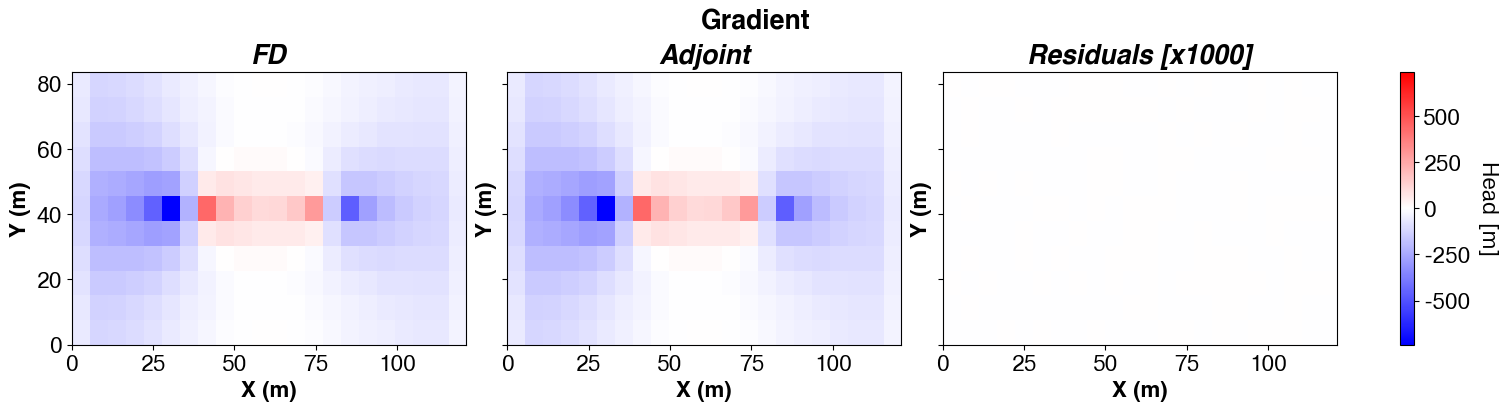

In [26]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (15, 4)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2", "ax1-3"]], sharey=True, sharex=True)
    },
)

time_index = 0
multi_imshow(
    axes=[plotter.get_axis(ax_name) for ax_name in ["ax1-1", "ax1-2", "ax1-3"]],
    data={
        # Warning: observation 0 matches sample 1
        "FD": param.archived_fd_gradients[0].reshape(nx, ny),
        "Adjoint": param.archived_adjoint_gradients[0].reshape(nx, ny),
        "Residuals [x1000]": (
            param.archived_fd_gradients[0].reshape(nx, ny)
            - param.archived_adjoint_gradients[0].reshape(nx, ny)
        )
        * 1000,
    },
    fig=plotter.fig,
    cbar_title="Head [m]",
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy], "cmap": "bwr"},
    xlabel="X (m)",
    ylabel="Y (m)",
    is_symetric_cbar=True,
)

plotter.subfigs["fig0"].suptitle("Gradient", fontweight="bold")
# plotter.subfigs["fig0"].supxlabel("X (m)", fontweight="bold")

fname = "1st_gradient_fd_vs_adjoint"
for format in ["png", "pdf"]:
    plotter.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Compute the observations LS loss function and regularization term (should be zero)

In [27]:
loss_ls = loss_ls = executor.scaled_loss_function(param.preconditioner(param.values))
loss_ls = loss_ls = executor.scaled_loss_function(param.preconditioner(param.values))
# get_model_ls_loss_function(model_adjusted, observables)
logging.info(f"LS loss function (SSE)= {loss_ls}")

loss_reg = get_model_reg_loss_function(model_adjusted, param)
logging.info(f"regularization loss function (SSE)= {loss_reg}")

INFO:root:- Running forward model # 1
INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 6999.729565879794
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.00014286266213404922
INFO:root:Loss (scaled)         = 1.0

INFO:root:- Running forward model # 2
INFO:root:- Run # 2 over
INFO:root:Loss (obs fit)        = 6999.72956587983
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.00014286266213404922
INFO:root:Loss (scaled)         = 1.0000000000000053

INFO:root:LS loss function (SSE)= 1.0000000000000053
INFO:root:regularization loss function (SSE)= 0.0


- Compute the LS loss gradient with respect to the parameters

In [28]:
grad_ls = (
    executor.scaled_loss_function_gradient(param.preconditioner(param.values))
    / executor.inv_model.scaling_factor
)

INFO:root:- Running gradient # 1
INFO:root:- Gradient eval # 1 over



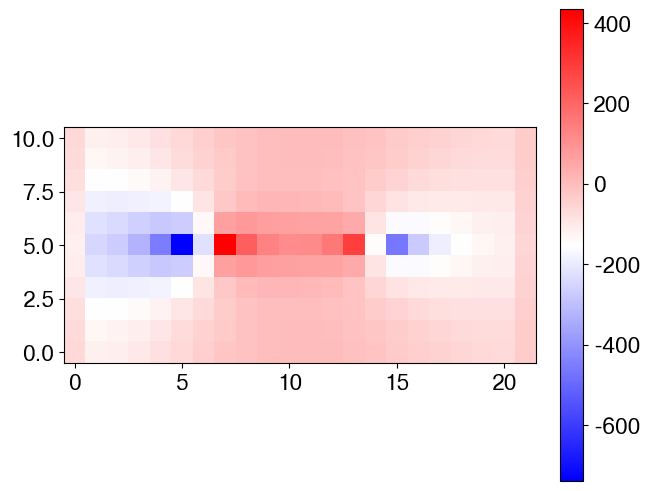

In [29]:
plt.imshow(param.archived_fd_gradients[0].reshape(nx, ny).T, origin="lower", cmap="bwr")
plt.colorbar()

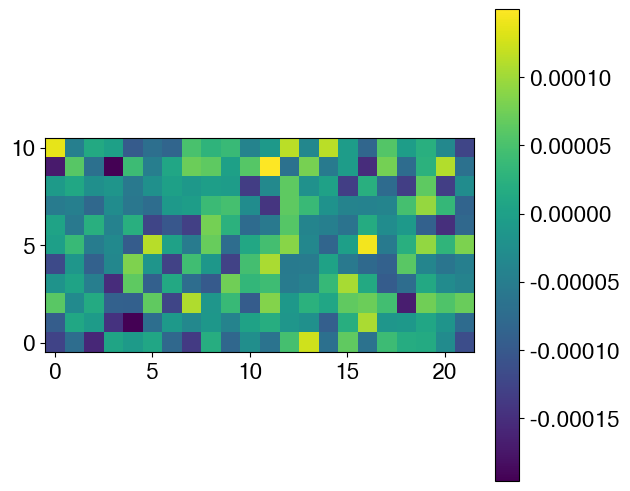

In [30]:
plt.imshow(
    (param.archived_fd_gradients[0] - param.archived_adjoint_gradients[0])
    .reshape(nx, ny)
    .T,
    origin="lower",
)
plt.colorbar()

In [31]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (15, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True)
    },
)

nb_frames = duration_in_days
plotter.animated_multi_imshow(
    ax_names=["ax1-1"],
    data={
        "Adjoint sources": executor.adj_model.a_fl_model.a_sources,
    },
    cbar_title="Head error [m]",
    nb_frames=nb_frames,
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Y (m)",
)

plotter.animated_multi_imshow(
    ax_names=["ax1-2"],
    data={
        "Adjoint head": executor.adj_model.a_fl_model.a_head,
    },
    cbar_title="Adjoit head",
    nb_frames=nb_frames,
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Y (m)",
)

plotter.subfigs["fig0"].suptitle("Adjoint sources and head", fontweight="bold")

plotter.close()
plotter.animate(nb_frames=nb_frames)

# Save the animation locally on the computer
fname_html = fig_save_path.joinpath(
    "head_field_reference_vs_initial_guess_animated.html"
)
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [32]:
res = executor.run()
print(res)

INFO:root:============================= Inversion Parameters =============================
INFO:root:Method                                            : L-BFGS-B
INFO:root:
INFO:root:Number of adjusted parameters                     : 1
INFO:root:Number of unknowns (adjusted values)              : 242
INFO:root:Number of observables                             : 2
INFO:root:Number of observation data points (values)        : 6
INFO:root:================================================================================
INFO:root:Entering optimization loop: 1
INFO:root:- Running forward model # 3
INFO:root:- Run # 3 over
INFO:root:Loss (obs fit)        = 6999.729490694159
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.00014286266213404922
INFO:root:Loss (scaled)         = 0.9999999892587801

INFO:root:- Running gradient # 2
INFO:root:- Gradient eval # 2 over

INFO:root:- Running forward model # 4
INFO:root:- Run # 4 over
INFO:root:Loss (obs fit)        = 6448.886

  message: STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 0.003260102268590402
        x: [ 1.398e+00  1.447e+00 ...  1.435e+00  1.352e+00]
      nit: 10
      jac: [-5.689e-05 -6.412e-05 ...  2.141e-06  2.249e-06]
     nfev: 11
     njev: 11
 hess_inv: <242x242 LbfgsInvHessProduct with dtype=float64>


In [33]:
adjusted_param = executor.inv_model.parameters_to_adjust[0]

In [34]:
plotter = AnimatedPlotter(
    fig_params={"figsize": (14.0, 8.0)}, subfigs_params={"nrows": 2, "ncols": 2}
)

# 1 frame per solver iteration
nb_frames: int = inverse_model.nb_f_calls

aligned_adjoint_gradients = get_gridded_archived_gradients(
    adjusted_param, is_adjoint=True
)

# 1) Gradient evolution
plotter.animated_multi_imshow(
    ax_names=["ax1-1"],
    data={
        "Gradient": aligned_adjoint_gradients,
    },
    # cbar_title="Adjoit head",
    nb_frames=nb_frames,
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy], "aspect": "equal"},
    xlabel="X (m)",
    ylabel="Y (m)",
)
plotter.get_axis("ax1-1").set_title("Gradient", fontweight="bold")

# 2) Parameter evolution
plotter.animated_multi_imshow(
    ax_names=["ax1-2"],
    data={
        "Permeability": np.transpose(
            np.array(adjusted_param.archived_values), axes=[1, 2, 0]
        ),
    },
    nb_frames=nb_frames,
    imshow_kwargs={
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "aspect": "equal",
        "norm": LogNorm(),
    },
    xlabel="X (m)",
    ylabel="Y (m)",
)

plotter.get_axis("ax1-1").set_title("Gradient", fontweight="bold")
xlabel = "Node #"

plotter.get_axis("ax1-2").set_title("Hydraulic conductivity field", fontweight="bold")
plotter.get_axis("ax1-2").set_xlabel("X (m)")
plotter.get_axis("ax1-2").set_ylabel("[m/s]")

# 3) Objective function
vals = inverse_model.list_f_res
obj_fun_vals = np.full((len(vals), nb_frames), fill_value=np.nan)
for i in range(len(vals)):
    obj_fun_vals[: i + 1, i] = vals[: i + 1]

plotter.animated_multi_plot(
    ax_name="ax2-1",
    data={
        "Obj fun": {"y": obj_fun_vals, "kwargs": {"c": "r", "linestyle": "--"}},
    },
    nb_frames=nb_frames,
    title="Objective function",
    xlabel="Iteration #",
)
plotter.ax_dict["ax2-1"].set_yscale("log")

# 4) Observation vs predicted values
pyrtid.plot.plot_observed_vs_simulated(
    plotter.ax_dict["ax2-2"],
    obs_vector=pyrtid.inverse.get_observables_values_as_1d_vector(observables),
    pred_vector=pyrtid.inverse.get_predictions_matching_observations(
        model_adjusted, observables
    ),
    pred_vector_initial=pyrtid.inverse.get_predictions_matching_observations(
        model_estimate, observables
    ),
    units="$mmol.l^{-1}$",
)

plotter.close()
plotter.animate(nb_frames=nb_frames)
# Save the animation locally on the computer
fname_html = fig_save_path.joinpath("m_j_g_animation.html")
writer = HTMLWriter(fps=2, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Extract the svg from the html file (for animation in Latex)
extract_frames_from_embedded_html_animation(fname_html)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


Inversion

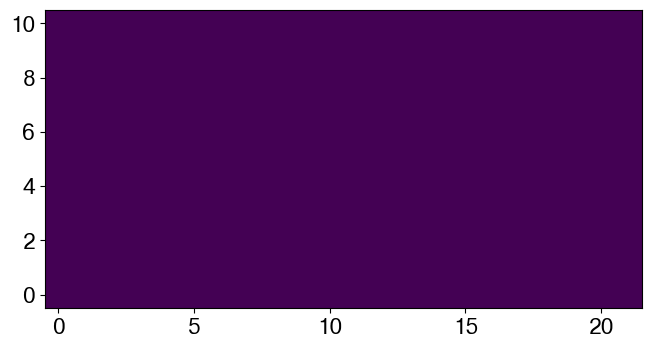

In [35]:
plt.imshow(param.get_regularization_loss_function_gradient().T, origin="lower")

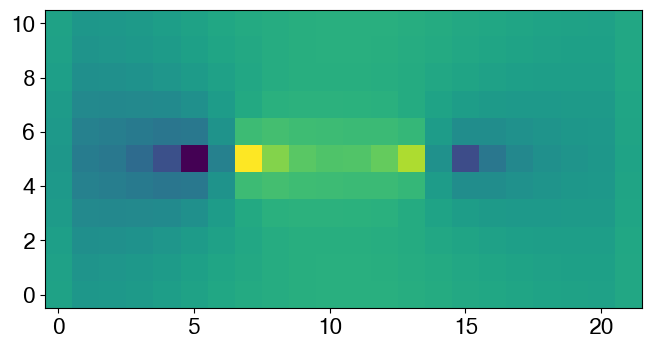

In [36]:
plt.imshow(
    get_gridded_archived_gradients(param, is_adjoint=True)[:, :, 0].T, origin="lower"
)

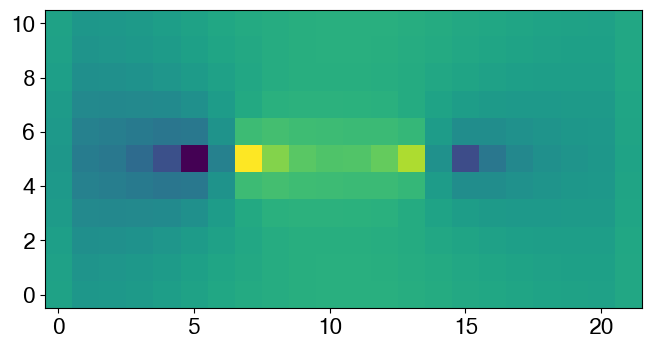

In [37]:
plt.imshow(
    get_gridded_archived_gradients(param, is_adjoint=False)[:, :, 0].T, origin="lower"
)

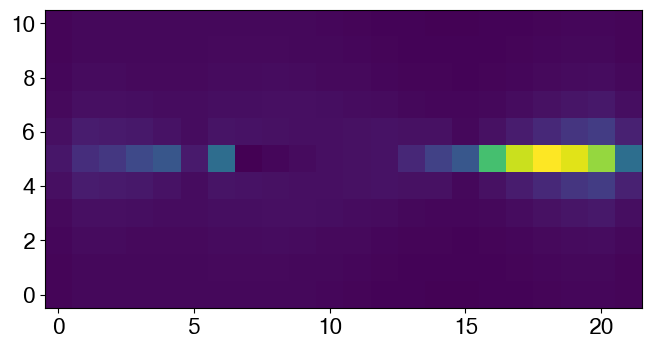

In [38]:
plt.imshow(param.values.T, origin="lower")

# Regularization

- Configuration for the inversion

In [39]:
# For now we use the exact parameters, we will complexify a bit later
prior_std = 1.0
len_scale: NDArrayFloat = np.array([100.0, 100.0, 1.0])


# Exponential covariance model
def exponential_kernel(r: float) -> NDArrayFloat:
    return (prior_std**2) * np.exp(-r)


# Gaussian covariance model
def gaussian_kernel(r: float) -> NDArrayFloat:
    return (prior_std**2) * np.exp(-(r**2))


# Create a covariance matrix
cov_mat_fft = FFTCovarianceMatrix(
    kernel=exponential_kernel,
    domain_shape=(nx, ny),
    mesh_dim=(dx, dy),
    len_scale=len_scale,
)
# cov_mat_fft = DenseCovarianceMatrix(pts, kernel=exponential_kernel)
# Compress the matrix by eigen decomposition
cov_mat_fft_eigen_64 = cov_mat_to_ud_mat(cov_mat_fft, n_pc=64)

INFO:root:Tree building time = 0.00026607513427734375
INFO:root:Nearest neighbor computation time = 0.002633333206176758
INFO:root:Elapsed time = 0.226054
INFO:root:Eigendecomposition of Prior Covariance
INFO:root:- time for eigendecomposition with k = 64 is 0 sec
INFO:root:- 1st eigv : 153.31, 64-th eigv : 0.0853102, ratio: 0.000556457


In [40]:
def inverse_function(x: NDArrayFloat) -> NDArrayFloat:
    """Return 1/x."""
    return 1 / x


param_reg = AdjustableParameter(
    name=ParameterName.PERMEABILITY,
    lbound=1e-6,
    ubound=0.1,
    preconditioner=permeability_to_log_transmitivity,
    preconditioner_1st_derivative=inverse_function,
    backconditioner=log_transmitivity_to_permeability,
    regularizators=[
        GeostatisticalRegularizator(cov_mat_fft_eigen_64, is_preconditioned=True)
    ],
)

# Create an executor to keep track of the adjoint model
solver_config_reg = ScipySolverConfig(
    solver_name="L-BFGS-B",
    solver_options={"maxfun": 2, "maxiter": 2, "ftol": 1e-10, "gtol": 1e-10},
    is_check_gradient=True,
    # max_optimization_round_nb=1,
    # max_fun_per_round=8,
    reg_factor=1000.0,
)
model_adjusted_reg = copy.deepcopy(model_estimate)
inverse_model_reg = InverseModel(param_reg, observables)
executor_reg = ScipyInversionExecutor(
    model_adjusted_reg, inverse_model_reg, solver_config_reg
)

# A bit to expensive to test the correctness of the gradient here...
is_grad_ok = executor_reg.is_adjoint_gradient_correct()
print("Is the gradient correct: ", is_grad_ok)

Is the gradient correct:  True


In [41]:
loss_reg = get_model_reg_loss_function(model_adjusted_reg, param_reg)
logging.info(f"regularization loss function (SSE)= {loss_reg}")

INFO:root:regularization loss function (SSE)= 0.9627371539641658


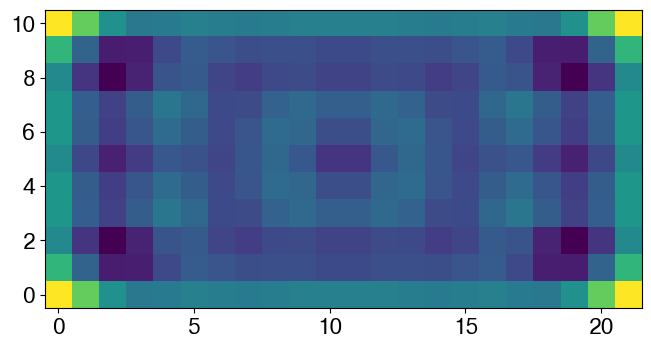

In [42]:
# Check the initial regularization gradient (note: we start from a constant field)
plt.imshow(param_reg.get_regularization_loss_function_gradient().T, origin="lower")

In [43]:
res = executor_reg.run()
logging.info(res)

INFO:root:============================= Inversion Parameters =============================
INFO:root:Method                                            : L-BFGS-B
INFO:root:
INFO:root:Number of adjusted parameters                     : 1
INFO:root:Number of unknowns (adjusted values)              : 242
INFO:root:Number of observables                             : 2
INFO:root:Number of observation data points (values)        : 6
INFO:root:================================================================================
INFO:root:Entering optimization loop: 1
INFO:root:- Running forward model # 1
INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 6999.729490694101
INFO:root:Loss (regularization) = 962.7375494880824
INFO:root:Scaling factor        = 0.00012558921687883304
INFO:root:Loss (scaled)         = 1.0

INFO:root:- Running gradient # 1
INFO:root:The adjoint gradient seems correct!
INFO:root:- Gradient eval # 1 over

INFO:root:- Running forward model # 2
INFO:root:- Run # 2 ov

In [44]:
adjusted_param = executor.inv_model.parameters_to_adjust[0]

In [45]:
plotter = AnimatedPlotter(
    fig_params={"figsize": (14.0, 8.0)}, subfigs_params={"nrows": 2, "ncols": 2}
)

# 1 frame per solver iteration
nb_frames: int = inverse_model.nb_f_calls

aligned_adjoint_gradients = get_gridded_archived_gradients(
    adjusted_param, is_adjoint=True
)

# 1) Gradient evolution
plotter.animated_multi_imshow(
    ax_names=["ax1-1"],
    data={
        "Gradient": aligned_adjoint_gradients,
    },
    # cbar_title="Adjoit head",
    nb_frames=nb_frames,
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy], "aspect": "equal"},
    xlabel="X (m)",
    ylabel="Y (m)",
)
plotter.get_axis("ax1-1").set_title("Gradient", fontweight="bold")

# 2) Parameter evolution
plotter.animated_multi_imshow(
    ax_names=["ax1-2"],
    data={
        "Permeability": np.transpose(
            np.array(adjusted_param.archived_values), axes=[1, 2, 0]
        ),
    },
    nb_frames=nb_frames,
    imshow_kwargs={
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "aspect": "equal",
        "norm": LogNorm(),
    },
    xlabel="X (m)",
    ylabel="Y (m)",
)

plotter.get_axis("ax1-2").set_title("Hydraulic conductivity field", fontweight="bold")
plotter.get_axis("ax1-2").set_xlabel("X (m)")
plotter.get_axis("ax1-2").set_ylabel("[m/s]")

# 3) Objective function
vals = inverse_model.list_f_res
obj_fun_vals = np.full((len(vals), nb_frames), fill_value=np.nan)
for i in range(len(vals)):
    obj_fun_vals[: i + 1, i] = vals[: i + 1]

plotter.animated_multi_plot(
    ax_name="ax2-1",
    data={
        "Obj fun": {"y": obj_fun_vals, "kwargs": {"c": "r", "linestyle": "--"}},
    },
    nb_frames=nb_frames,
    title="Objective function",
    xlabel="Iteration #",
)
plotter.ax_dict["ax2-1"].set_yscale("log")

# 4) Observation vs predicted values
pyrtid.plot.plot_observed_vs_simulated(
    plotter.ax_dict["ax2-2"],
    obs_vector=pyrtid.inverse.get_observables_values_as_1d_vector(observables) * 1000,
    pred_vector=pyrtid.inverse.get_predictions_matching_observations(
        model_adjusted, observables
    )
    * 1000,
    pred_vector_initial=pyrtid.inverse.get_predictions_matching_observations(
        model_estimate, observables
    )
    * 1000,
    units="$mmol.l^{-1}$",
)

plotter.close()
plotter.animate(nb_frames=nb_frames)
# Save the animation locally on the computer
fname_html = fig_save_path.joinpath("m_j_g_animation.html")
writer = HTMLWriter(fps=2, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Extract the svg from the html file (for animation in Latex)
extract_frames_from_embedded_html_animation(fname_html)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


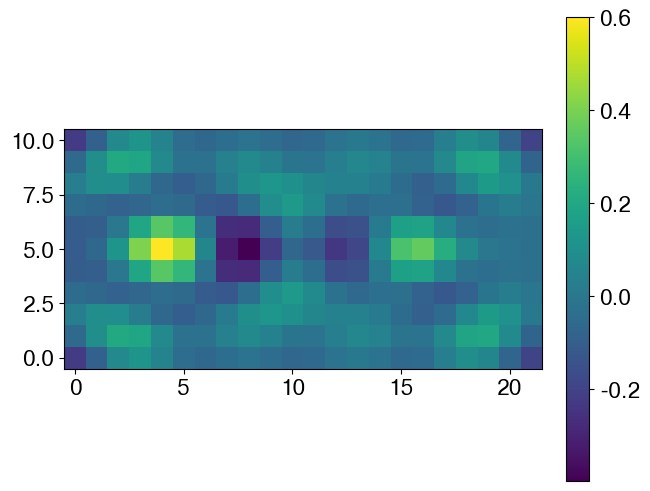

In [46]:
# Check the initial regularization gradient (note: we start from a constant field)
plt.imshow(param_reg.get_regularization_loss_function_gradient().T, origin="lower")
plt.colorbar()

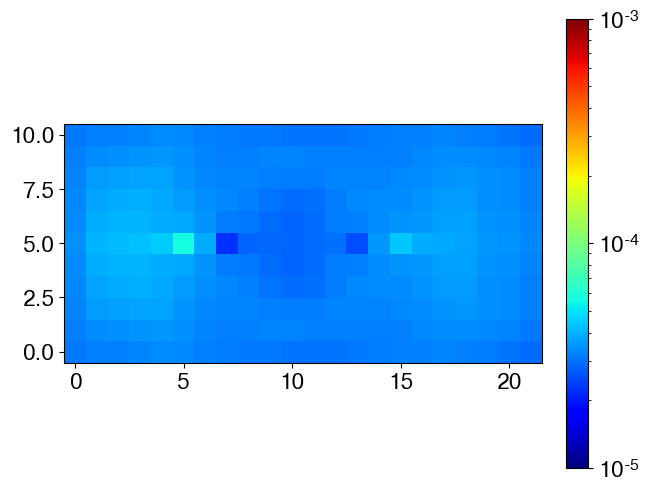

In [47]:
# Check the initial regularization gradient (note: we start from a constant field)
plt.imshow(
    param_reg.values.T,
    origin="lower",
    norm=LogNorm(vmin=1e-5, vmax=1e-3),
    cmap=plt.get_cmap("jet"),
)
plt.colorbar()

# Uncertainty estimation

Compute the uncertainty from the diagonal of the Hessian approximated by L-BFGS-B

In [48]:
exact_hess = np.linalg.inv(res.hess_inv.todense())  # This is the real hessian

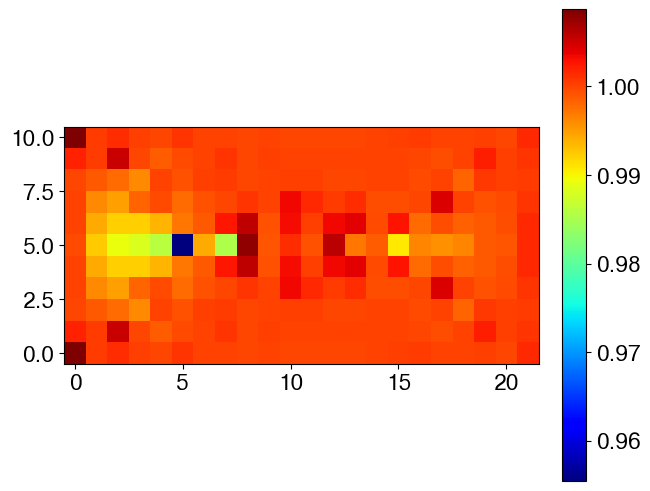

In [49]:
exact_hess_diag = np.diagonal(exact_hess)
plt.imshow(
    np.sqrt(exact_hess_diag).reshape(nx, ny).T,
    origin="lower",
    aspect="equal",
    cmap=plt.get_cmap("jet"),
)
plt.colorbar()

In [50]:
# Get only the diagonal of the hessian solving Ax = b for all vectors of the identity matrix

import numpy as np
from scipy.optimize import LbfgsInvHessProduct
from scipy.sparse.linalg import LinearOperator, lgmres

from pyrtid.utils.types import NDArrayFloat


def get_hess_diag_not_working(hess_inv: LbfgsInvHessProduct) -> NDArrayFloat:
    """
    Extract efficiently the diagonal of the L-BFGS approximate Hessian.

    NOT WORKING !

    It relies on the linear operator `matvec` operation and consequenlty does not
    require to build the dense matrix which is much longer and generally untractable
    for large-scale problems.

    Parameters
    ----------
    hess_inv : LbfgsInvHessProduct
        Linear operator for the L-BFGS approximate inverse Hessian.

    Returns
    -------
    NDArrayFloat
        The diagonal of the L-BFGS approximated inverse Hessian.
    """
    n_params = hess_inv.shape[0]
    hess_diag = np.zeros(n_params)  # hessian diagonal
    for i in range(n_params):
        # construct the ith row of the identity matrix
        v = np.zeros(n_params)
        v[i] = 1.0
        # u = Hv -> Solve H^{-1}u = v, and get the ith element of u to get the
        # diagonal element of H
        hess_diag[i] = np.linalg.solve(hess_inv, v)[i]
    return hess_diag


def get_hess_diag(hess_inv: LbfgsInvHessProduct) -> NDArrayFloat:
    """
    Extract efficiently the diagonal of the L-BFGS approximate Hessian.

    It relies on the linear operator `matvec` operation and consequenlty does not
    require to build the dense matrix which is much longer and generally untractable
    for large-scale problems.

    Parameters
    ----------
    hess_inv : LbfgsInvHessProduct
        Linear operator for the L-BFGS approximate inverse Hessian.

    Returns
    -------
    NDArrayFloat
        The diagonal of the L-BFGS approximated inverse Hessian.
    """
    n_params = hess_inv.shape[0]
    hess_diag = np.zeros(n_params)  # hessian diagonal
    # We must build a LinearOperator to work with sparse solvers
    linop = LinearOperator(
        dtype=np.float64, shape=res.hess_inv.shape, matvec=res.hess_inv.matvec
    )

    # Potential to parallelize the computation
    for i in range(n_params):
        # construct the ith row of the identity matrix
        v = np.zeros(n_params)
        v[i] = 1.0
        # u = Hv -> Solve H^{-1}u = v, and get the ith element of u to get the
        # diagonal element of H
        # Solve a sparse system, using matvec operations only
        x, info = lgmres(linop, v, atol=1e-10)
        hess_diag[i] = x[i]
        # = hess_inv.matvec(v)[i]
    return hess_diag

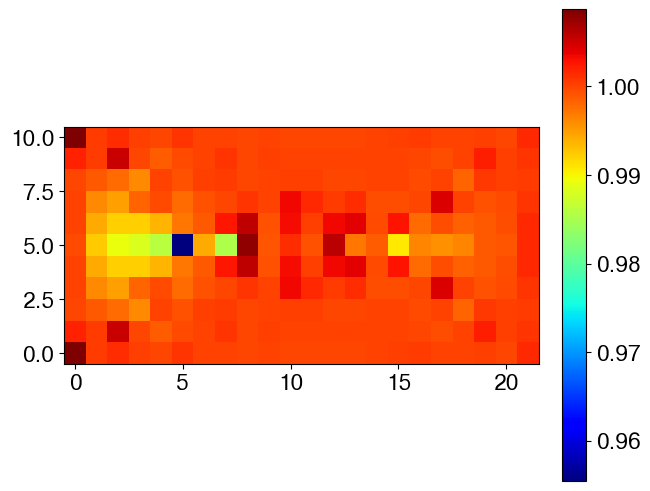

In [51]:
approx_hess_diag = get_hess_diag(res.hess_inv)

plt.imshow(
    np.sqrt(approx_hess_diag).reshape(nx, ny).T,
    origin="lower",
    aspect="equal",
    cmap=plt.get_cmap("jet"),
)
plt.colorbar()

- Check if the residuals are the same

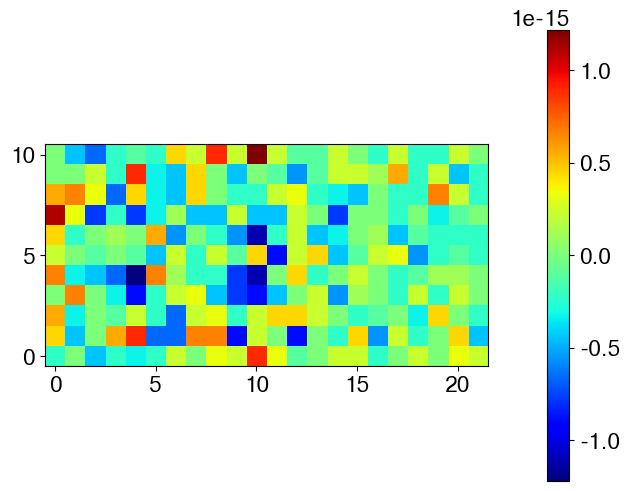

In [52]:
plt.imshow(
    (np.sqrt(approx_hess_diag) - np.sqrt(exact_hess_diag)).reshape(nx, ny).T,
    origin="lower",
    aspect="equal",
    cmap=plt.get_cmap("jet"),
)
plt.colorbar()

- The following is not correct !

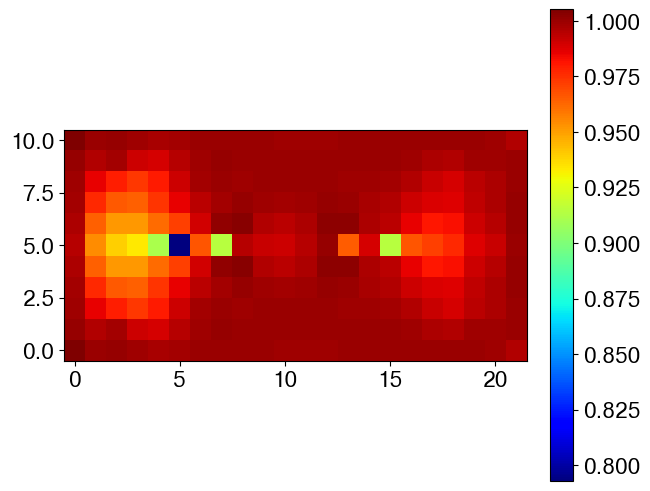

In [53]:
plt.imshow(
    1 / np.sqrt(extract_hess_inv_diag(res.hess_inv)).reshape(nx, ny).T,
    origin="lower",
    aspect="equal",
    cmap=plt.get_cmap("jet"),
)
plt.colorbar()